<a href="https://colab.research.google.com/github/mostafadentist/healthcare-data-analytics/blob/main/sgh_pycaret_2_more_models_to_select_from.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install --upgrade packaging -q
!pip install --upgrade numpy pandas pycaret[full] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-core 0.3.68 requires packaging<25,>=23.2, but you have packaging 25.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
# check installed version
import pycaret
pycaret.__version__


'3.3.2'

In [12]:
import pandas as pd
from datetime import datetime
from pycaret.classification import ClassificationExperiment

# === Load dataset ===
data = pd.read_excel('/content/Data_DM - Copy.xlsx', sheet_name='Data_Set')

# Define main columns
target_col = 'Chronic_flag'
id_col     = 'Unique_Identifier'

# === Convert D_Of_Birth → Age ===
if 'D_Of_Birth' in data.columns:
    data['D_Of_Birth'] = pd.to_datetime(data['D_Of_Birth'], errors='coerce')
    today = pd.Timestamp(datetime.today().date())
    data['Age'] = (
        today.year - data['D_Of_Birth'].dt.year
        - ((today.month < data['D_Of_Birth'].dt.month) |
           ((today.month == data['D_Of_Birth'].dt.month) & (today.day < data['D_Of_Birth'].dt.day)))
    )
    data = data.drop(columns=['D_Of_Birth'])

# === Fix Avg_HBA1C Results (numeric if possible) ===
if 'Avg_HBA1C Results' in data.columns:
    data['Avg_HBA1C Results'] = pd.to_numeric(data['Avg_HBA1C Results'], errors='coerce')

# ----------------------------------------------------------
# HARD-CODE FEATURE TYPES
# ----------------------------------------------------------

categorical_features = [
    'Gender',
    'Religion',
    'Nationality',
    'HBA1C test Compliance',
    'Diagnosis_Type',
    'Acute_flag',
    'ER_flag_bef_chronic',
    'IP_flag_bef_chr',
    'Comorbidity',
    'Atrial Fibrilation',         # note spelling in dataset
    'Cancer',
    'Cardio Vascular Disease',    # note space
    'Perepheral Artery Disease',  # note spelling
    'Renal Insufficiency',
    'Heart Failure',
    'Hypertension',
    'Ischemic Heart Disease',
    'Myocardial Infarction',
    'Obesity',
    'Stroke'
]

numeric_features = [
    'Age',
    'Avg_HBA1C Results',
    '# ER_befor_Chr',    # use exactly as in dataset
    '# IP_bef_chr',
    '# OP_Bef_chr'
]

ignore_features = ['Unique_Identifier']








In [ ]:
data

,Unique_Identifier,Gender,Religion,Nationality,Avg_HBA1C Results,HBA1C test Compliance,Diagnosis_Type,Chronic_flag,Acute_flag,ER_flag_bef_chronic,...,Cardio Vascular Disease,Perepheral Artery Disease,Renal Insufficiency,Heart Failure,Hypertension,Ischemic Heart Disease,Myocardial Infarction,Obesity,Stroke,Age
0,SGH11015,Male,OTHER,PALASTINIAN,5.438750,Non Compliant,Type II,0,0,0,...,0,0,0,0,0,0,0,0,0,51
1,SGH11016,Male,OTHER,Saudi,6.186032,Compliant,Type II,0,0,0,...,0,0,0,0,0,0,0,0,0,49
2,SGH11017,Female,OTHER,Saudi,6.099180,Compliant,Type II,0,0,0,...,0,0,0,0,1,0,0,0,0,70
3,SGH11018,Male,OTHER,Saudi,8.804544,Non Compliant,Type II,0,0,0,...,0,0,0,0,1,0,0,0,0,51
4,SGH11019,Male,OTHER,Saudi,8.232722,Compliant,Type II,0,0,0,...,0,0,0,0,0,0,0,0,0,71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12606,SGH11012621,Male,Islam,Nigerian,8.400000,Non Compliant,Type II,0,0,0,...,0,0,0,0,0,0,0,0,0,58
12607,SGH11012622,Female,Islam,Saudi,7.400000,Non Compliant,Type II,0,0,0,...,0,0,0,0,0,0,0,0,0,51
12608,SGH11012623,Female,Islam,Saudi,5.900000,Non Compliant,Type II,0,0,0,...,0,0,0,0,1,0,0,0,0,62
12609,SGH11012624,Female,Islam,Saudi,5.200000,Non Compliant,Type II,0,0,0,...,0,0,0,0,0,0,0,0,0,40


In [ ]:
print(data.columns.tolist())

['Unique_Identifier', 'Gender', 'Religion', 'Nationality', 'Avg_HBA1C Results', 'HBA1C test Compliance', 'Diagnosis_Type', 'Chronic_flag', 'Acute_flag', 'ER_flag_bef_chronic', '# ER_befor_Chr', 'IP_flag_bef_chr', '# IP_bef_chr', '# OP_Bef_chr', 'Comorbidity', 'Atrial Fibrilation', 'Cancer', 'Cardio Vascular Disease', 'Perepheral Artery Disease', 'Renal Insufficiency', 'Heart Failure', 'Hypertension', 'Ischemic Heart Disease', 'Myocardial Infarction', 'Obesity', 'Stroke', 'Age']


In [5]:
# import ClassificationExperiment and init the class
from pycaret.classification import ClassificationExperiment
exp = ClassificationExperiment()

In [ ]:
# check the type of exp
type(exp)

pycaret.classification.oop.ClassificationExperiment

In [13]:
# ----------------------------------------------------------
# Setup Experiment
# ----------------------------------------------------------

exp = ClassificationExperiment()

exp.setup(
    data=data,
    target=target_col,
    session_id=123,
    ignore_features=ignore_features,
    categorical_features=categorical_features,
    numeric_features=numeric_features,
    fix_imbalance=True,  # helpful if dataset imbalanced
    use_gpu=False
)

# Compare all models
best_models = exp.compare_models(n_select=10, sort='AUC')

,Description,Value
0,Session id,123
1,Target,Chronic_flag
2,Target type,Binary
3,Original data shape,"(12611, 27)"
4,Transformed data shape,"(16416, 51)"
5,Transformed train set shape,"(12632, 51)"
6,Transformed test set shape,"(3784, 51)"
7,Ignore features,1
8,Numeric features,5
9,Categorical features,20


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.8880,0.8716,0.6475,0.9405,0.7666,0.6962,0.7174,3.2170
gbc,Gradient Boosting Classifier,0.8895,0.8710,0.6444,0.9523,0.7682,0.6993,0.7225,2.2270
lightgbm,Light Gradient Boosting Machine,0.8850,0.8691,0.6527,0.9208,0.7633,0.6903,0.7085,2.0390
catboost,CatBoost Classifier,0.8867,0.8685,0.6515,0.9296,0.7657,0.6941,0.7134,15.9470
ada,Ada Boost Classifier,0.8886,0.8654,0.6507,0.9397,0.7685,0.6984,0.7191,1.0990
svm,SVM - Linear Kernel,0.8171,0.8631,0.7049,0.8039,0.7122,0.5908,0.6240,1.0630
xgboost,Extreme Gradient Boosting,0.8808,0.8620,0.6551,0.8988,0.7574,0.6810,0.6963,1.0960
nb,Naive Bayes,0.8914,0.8614,0.6483,0.9556,0.7723,0.7044,0.7274,0.6870
rf,Random Forest Classifier,0.8652,0.8513,0.6766,0.8184,0.7405,0.6506,0.6562,1.7840
et,Extra Trees Classifier,0.8576,0.8401,0.6754,0.7935,0.7295,0.6337,0.6377,2.4710


Processing:   0%|          | 0/78 [00:00<?, ?it/s]

 Key metrics (from your results)
Accuracy: highest around 0.8914 (Naive Bayes) and 0.8895 (Gradient Boosting).
AUC (discrimination power): strongest with Logistic Regression (0.8716) and Gradient Boosting (0.8710).
Recall (Sensitivity): best with XGBoost (0.6551), LightGBM (0.6527), Logistic Regression (0.6475).
Precision: best with Naive Bayes (0.9556) and Gradient Boosting (0.9523).
F1 (balance of precision/recall): top values are Naive Bayes (0.7723), AdaBoost (0.7685), Gradient Boosting (0.7682).
Kappa/MCC (agreement beyond chance): strongest with Naive Bayes (0.7044/0.7274), Logistic Regression (0.6962/0.7174), and Gradient Boosting (0.6993/0.7225).
Training time: some models (CatBoost 15 sec) costlier than others (AdaBoost 1 sec, Logistic 3 sec).
🏆 Best overall models
Looking at balanced metrics (Accuracy, AUC, F1, Kappa/MCC):

Naive Bayes (nb)

Accuracy: 0.8914 (highest)
AUC: respectable (0.8614)
Precision: 0.9556 (very low false positives)
F1: 0.7723 (best overall balance)
Extra: runs extremely fast.
Gradient Boosting (gbc)

Accuracy: 0.8895
AUC: 0.8710 (2nd best overall diagnostic power)
Precision: 0.9523, F1: 0.7682
Solid across the board.
Logistic Regression (lr)

Accuracy: 0.8880
AUC best: 0.8716 (great calibration/ROC curve)
F1: 0.7666 (very good balance)
Interpretable model with coefficients (important in healthcare).
⚖️ Which to choose depends on goal
If interpretability is most important (e.g. in healthcare context):
→ Logistic Regression (easiest to explain with odds ratios, features significance).

If you want the absolute top performance with high recall & precision:
→ Naive Bayes or Gradient Boosting (better F1 + precision).

If you plan deployment at scale (fast inference):
→ Naive Bayes (lightweight, very high precision, extremely fast).

If you want powerful flexible model with feature importance plots & non‑linear interactions:
→ Gradient Boosting or CatBoost (slightly heavier but good trade‑off).

In [22]:
# The compare_models function returns a list of models when n_select > 1,
# so we need to select the best model from the list.
best = best_models[0]
best

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [ ]:
# Create the best model
model = exp.create_model(best)

# Evaluate
exp.evaluate_model(model)

# Finalize for deployment
final_model = exp.finalize_model(model)

# Predict on holdout set
preds = exp.predict_model(final_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8845,0.8368,0.6175,0.9627,0.7524,0.6817,0.7103
1,0.8947,0.8714,0.6574,0.9593,0.7801,0.7140,0.7361
2,0.8867,0.8481,0.6135,0.9809,0.7549,0.6863,0.7182
3,0.8856,0.8723,0.6135,0.9747,0.7531,0.6836,0.7146
4,0.8845,0.8654,0.6175,0.9627,0.7524,0.6817,0.7103
5,0.8935,0.8770,0.6454,0.9701,0.7751,0.7090,0.7343
6,0.8981,0.8768,0.6508,0.9880,0.7847,0.7216,0.7486
7,0.8968,0.8781,0.6574,0.9706,0.7838,0.7193,0.7429
8,0.9048,0.8861,0.6892,0.9665,0.8047,0.7440,0.7626


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9109,0.9490,0.6890,0.9973,0.8149,0.7589,0.7814


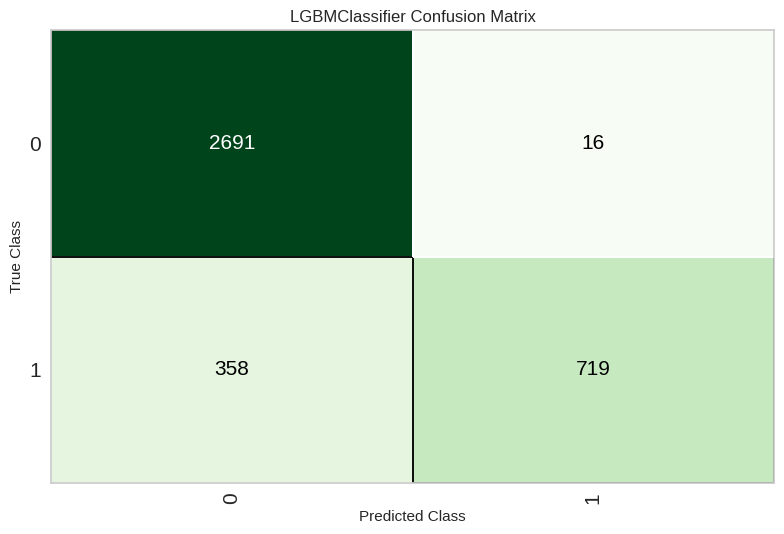

In [ ]:
exp.plot_model(best, plot='confusion_matrix')

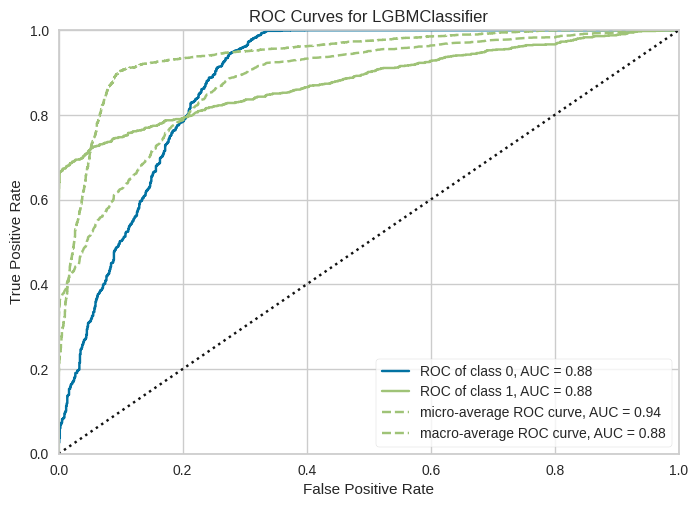

In [ ]:
# plot AUC
exp.plot_model(best, plot = 'auc')

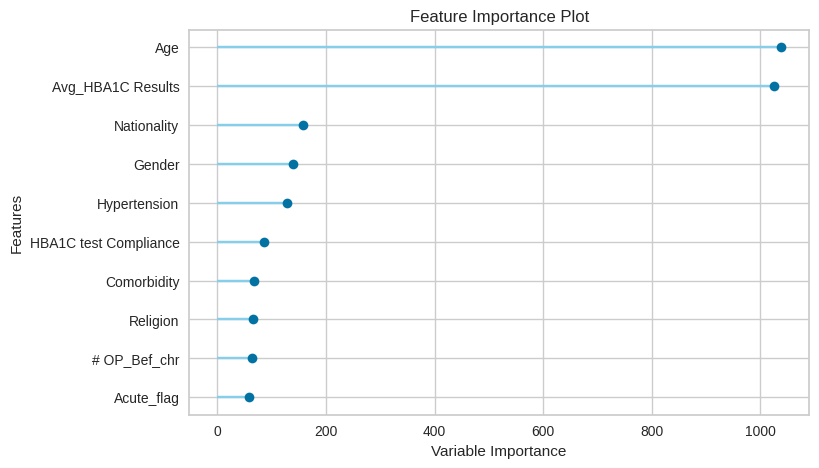

In [ ]:
# plot feature importance
exp.plot_model(best, plot = 'feature')

In [ ]:
exp.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
# Predict on test/holdout set
holdout_pred = exp.predict_model(best)

# Show first few predictions
holdout_pred.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9012,0.8825,0.6676,0.9782,0.7936,0.7316,0.7547


,Gender,Religion,Nationality,Avg_HBA1C Results,HBA1C test Compliance,Diagnosis_Type,Acute_flag,ER_flag_bef_chronic,# ER_befor_Chr,IP_flag_bef_chr,...,Heart Failure,Hypertension,Ischemic Heart Disease,Myocardial Infarction,Obesity,Stroke,Age,Chronic_flag,prediction_label,prediction_score
12377,Female,Islam,Saudi,5.882722,Compliant,Type II,0,0,0,0,...,0,1,0,0,0,0,54,0,0,0.9279
7147,Male,Islam,SAUDI,5.744563,Non Compliant,Type II,0,0,0,0,...,0,0,0,0,0,0,38,0,0,0.8891
7058,Male,Islam,SAUDI,5.300000,Non Compliant,Type II,0,0,0,0,...,0,1,0,0,0,0,55,0,0,0.8656
2947,Male,JEWISH,Saudi,5.720577,Compliant,Type II,0,0,0,0,...,0,0,0,0,0,0,33,0,0,0.9816
4459,Male,Unknown,SAUDI,7.174073,Non Compliant,Type II,0,0,0,0,...,0,0,0,0,0,0,45,0,0,0.6302


In [ ]:
# show predictions df
holdout_pred.head()

,Gender,Religion,Nationality,Avg_HBA1C Results,HBA1C test Compliance,Diagnosis_Type,Acute_flag,ER_flag_bef_chronic,# ER_befor_Chr,IP_flag_bef_chr,...,Heart Failure,Hypertension,Ischemic Heart Disease,Myocardial Infarction,Obesity,Stroke,Age,Chronic_flag,prediction_label,prediction_score
12377,Female,Islam,Saudi,5.882722,Compliant,Type II,0,0,0,0,...,0,1,0,0,0,0,54,0,0,0.9279
7147,Male,Islam,SAUDI,5.744563,Non Compliant,Type II,0,0,0,0,...,0,0,0,0,0,0,38,0,0,0.8891
7058,Male,Islam,SAUDI,5.300000,Non Compliant,Type II,0,0,0,0,...,0,1,0,0,0,0,55,0,0,0.8656
2947,Male,JEWISH,Saudi,5.720577,Compliant,Type II,0,0,0,0,...,0,0,0,0,0,0,33,0,0,0.9816
4459,Male,Unknown,SAUDI,7.174073,Non Compliant,Type II,0,0,0,0,...,0,0,0,0,0,0,45,0,0,0.6302


In [ ]:
# copy data and drop Class variable

new_data = data.copy()
new_data.drop('Chronic_flag', axis=1, inplace=True)
new_data.head()

,Unique_Identifier,Gender,Religion,Nationality,Avg_HBA1C Results,HBA1C test Compliance,Diagnosis_Type,Acute_flag,ER_flag_bef_chronic,# ER_befor_Chr,...,Cardio Vascular Disease,Perepheral Artery Disease,Renal Insufficiency,Heart Failure,Hypertension,Ischemic Heart Disease,Myocardial Infarction,Obesity,Stroke,Age
0,SGH11015,Male,OTHER,PALASTINIAN,5.438750,Non Compliant,Type II,0,0,0,...,0,0,0,0,0,0,0,0,0,51
1,SGH11016,Male,OTHER,Saudi,6.186032,Compliant,Type II,0,0,0,...,0,0,0,0,0,0,0,0,0,49
2,SGH11017,Female,OTHER,Saudi,6.099180,Compliant,Type II,0,0,0,...,0,0,0,0,1,0,0,0,0,70
3,SGH11018,Male,OTHER,Saudi,8.804544,Non Compliant,Type II,0,0,0,...,0,0,0,0,1,0,0,0,0,51
4,SGH11019,Male,OTHER,Saudi,8.232722,Compliant,Type II,0,0,0,...,0,0,0,0,0,0,0,0,0,71


In [ ]:
# predict model on new_data
predictions = exp.predict_model(best, data = new_data)
predictions.head()

,Unique_Identifier,Gender,Religion,Nationality,Avg_HBA1C Results,HBA1C test Compliance,Diagnosis_Type,Acute_flag,ER_flag_bef_chronic,# ER_befor_Chr,...,Renal Insufficiency,Heart Failure,Hypertension,Ischemic Heart Disease,Myocardial Infarction,Obesity,Stroke,Age,prediction_label,prediction_score
0,SGH11015,Male,OTHER,PALASTINIAN,5.438750,Non Compliant,Type II,0,0,0,...,0,0,0,0,0,0,0,51,0,0.9833
1,SGH11016,Male,OTHER,Saudi,6.186032,Compliant,Type II,0,0,0,...,0,0,0,0,0,0,0,49,0,0.9645
2,SGH11017,Female,OTHER,Saudi,6.099180,Compliant,Type II,0,0,0,...,0,0,1,0,0,0,0,70,0,0.9536
3,SGH11018,Male,OTHER,Saudi,8.804544,Non Compliant,Type II,0,0,0,...,0,0,1,0,0,0,0,51,0,0.9337
4,SGH11019,Male,OTHER,Saudi,8.232722,Compliant,Type II,0,0,0,...,0,0,0,0,0,0,0,71,0,0.9108


In [ ]:
# save pipeline
exp.save_model(best, 'my_first_pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Avg_HBA1C Results',
                                              '# ER_befor_Chr', '# IP_bef_chr',
                                              '# OP_Bef_chr', 'Comorbidity',
                                              'Age'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('categorical_imputer',...
                  LGBMClassifier(boosting_type='gbdt',

In [ ]:
# load pipeline
loaded_best_pipeline = exp.load_model('my_first_pipeline')
loaded_best_pipeline

Transformation Pipeline and Model Successfully Loaded


Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Avg_HBA1C Results',
                                             '# ER_befor_Chr', '# IP_bef_chr',
                                             '# OP_Bef_chr', 'Comorbidity',
                                             'Age'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='mean'))),
                ('categorica...
                 LGBMClassifier(boosting_type='gbdt', class_weight=None,
                                colsample_bytree=1.0, importance_type='split',
                                learning_rate=0.1, max_depth=-1,
                                min_child_samples=20, min_child_weight=0.001,
                                min_split_gain=0.0, n_estimators=100, n_jobs=-1,
                                num_leaves=31, objective=None, random_state=123,
                                reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
                                subsample_for_bin=200000, subsample_freq=0))],
         verbose=False)

In [ ]:
# check all available config
exp.get_config()

{'USI',
 'X',
 'X_test',
 'X_test_transformed',
 'X_train',
 'X_train_transformed',
 'X_transformed',
 '_available_plots',
 '_ml_usecase',
 'data',
 'dataset',
 'dataset_transformed',
 'exp_id',
 'exp_name_log',
 'fix_imbalance',
 'fold_generator',
 'fold_groups_param',
 'fold_shuffle_param',
 'gpu_n_jobs_param',
 'gpu_param',
 'html_param',
 'idx',
 'is_multiclass',
 'log_plots_param',
 'logging_param',
 'memory',
 'n_jobs_param',
 'pipeline',
 'seed',
 'target_param',
 'test',
 'test_transformed',
 'train',
 'train_transformed',
 'variable_and_property_keys',
 'variables',
 'y',
 'y_test',
 'y_test_transformed',
 'y_train',
 'y_train_transformed',
 'y_transformed'}

In [ ]:
# lets access X_train_transformed
exp.get_config('X_train_transformed')

,Gender,Religion,Nationality,Avg_HBA1C Results,HBA1C test Compliance,Diagnosis_Type,Acute_flag,ER_flag_bef_chronic,# ER_befor_Chr,IP_flag_bef_chr,...,Cardio Vascular Disease,Perepheral Artery Disease,Renal Insufficiency,Heart Failure,Hypertension,Ischemic Heart Disease,Myocardial Infarction,Obesity,Stroke,Age
11639,Male,Islam,LEBANESE,5.500000,Compliant,Type II,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,48.0
10360,Female,Islam,Saudi,6.130000,Non Compliant,Type II,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54.0
11305,Male,Islam,YEMENI,6.812645,Non Compliant,Type II,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,44.0
5787,Male,Islam,Jordanian,6.812645,Non Compliant,Type II,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,63.0
8163,Male,Islam,SAUDI,6.200000,Non Compliant,Type II,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6510,Female,Islam,Saudi,6.812645,Non Compliant,Type II,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0
4257,Male,ISLAM,SAUDI,8.800000,Non Compliant,Type II,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,59.0
479,Female,OTHER,Saudi,5.699123,Non Compliant,Type II,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36.0
9984,Female,Islam,Saudi,5.200000,Non Compliant,Type II,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0


<Axes: >

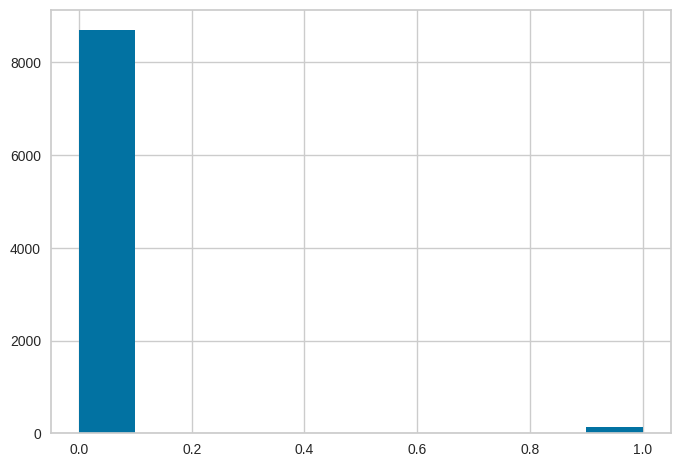

In [ ]:
# lets check the X_train_transformed to see effect of params passed
exp.get_config('X_train_transformed')['ER_flag_bef_chronic'].hist()

In [ ]:
compare_tree_models = exp.compare_models(include = ['dt', 'rf', 'et', 'gbc', 'xgboost', 'lightgbm', 'catboost'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8924,0.8673,0.6412,0.9706,0.7719,0.7054,0.7315,1.8170


Processing:   0%|          | 0/33 [00:00<?, ?it/s]

In [ ]:
best_recall_models_top3 = exp.compare_models(sort = 'Recall', n_select = 3)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8924,0.8673,0.6412,0.9706,0.7719,0.7054,0.7315,1.4400
dummy,Dummy Classifier,0.7155,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3510


Processing:   0%|          | 0/71 [00:00<?, ?it/s]

In [ ]:
# check available metrics used in CV
exp.get_metrics()

,Name,Display Name,Score Function,Scorer,Target,Args,Greater is Better,Multiclass,Custom
ID,,,,,,,,,
acc,Accuracy,Accuracy,<function accuracy_score at 0x7fada3810b80>,accuracy,pred,{},True,True,False
auc,AUC,AUC,<pycaret.internal.metrics.BinaryMulticlassScor...,"make_scorer(roc_auc_score, response_method=('d...",pred_proba,"{'average': 'weighted', 'multi_class': 'ovr'}",True,True,False
recall,Recall,Recall,<pycaret.internal.metrics.BinaryMulticlassScor...,"make_scorer(recall_score, response_method='pre...",pred,{'average': 'weighted'},True,True,False
precision,Precision,Prec.,<pycaret.internal.metrics.BinaryMulticlassScor...,"make_scorer(precision_score, response_method='...",pred,{'average': 'weighted'},True,True,False
f1,F1,F1,<pycaret.internal.metrics.BinaryMulticlassScor...,"make_scorer(f1_score, response_method='predict...",pred,{'average': 'weighted'},True,True,False
kappa,Kappa,Kappa,<function cohen_kappa_score at 0x7fada3810f40>,"make_scorer(cohen_kappa_score, response_method...",pred,{},True,True,False
mcc,MCC,MCC,<function matthews_corrcoef at 0x7fada38111c0>,"make_scorer(matthews_corrcoef, response_method...",pred,{},True,True,False


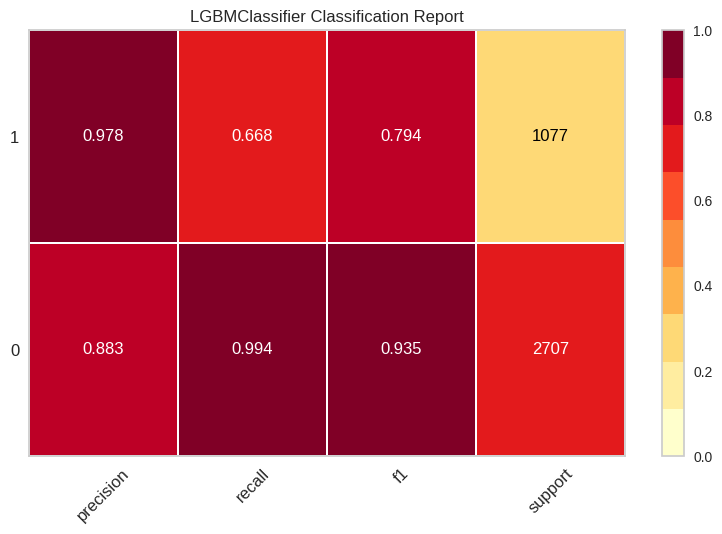

In [ ]:
# plot class report
exp.plot_model(best, plot = 'class_report')

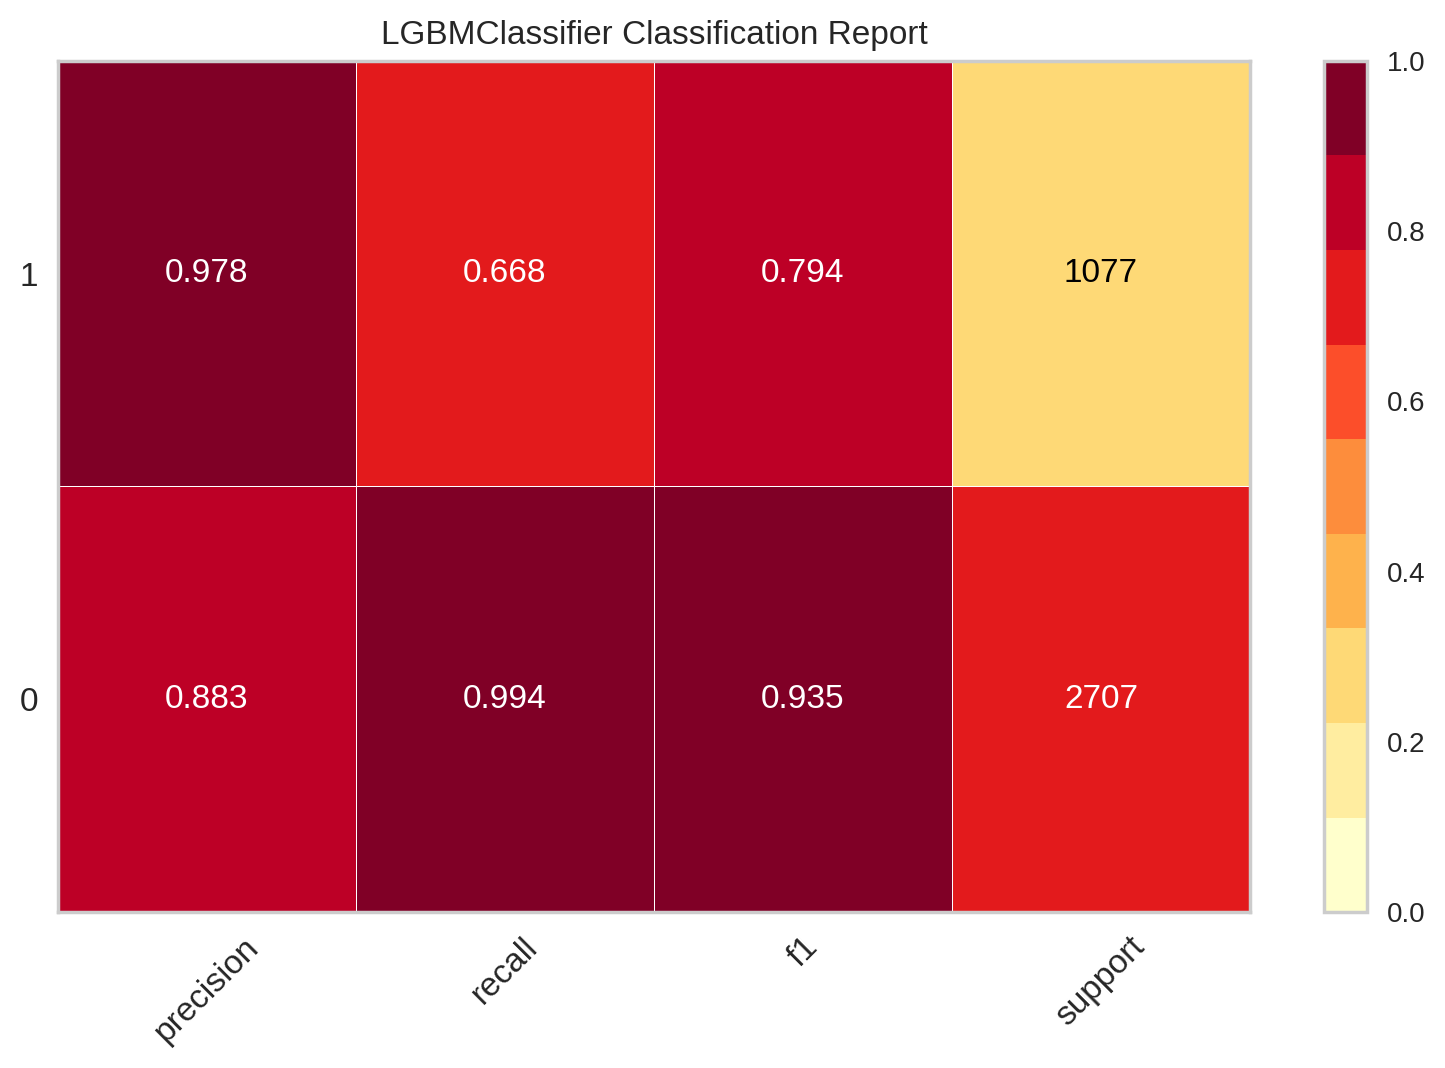

In [ ]:
# to control the scale of plot
exp.plot_model(best, plot = 'class_report', scale = 2)

In [ ]:
all_models = exp.compare_models(n_select=len(exp.models()))

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8924,0.8673,0.6412,0.9706,0.7719,0.7054,0.7315,2.6930
dummy,Dummy Classifier,0.7155,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2700


Processing:   0%|          | 0/84 [00:00<?, ?it/s]

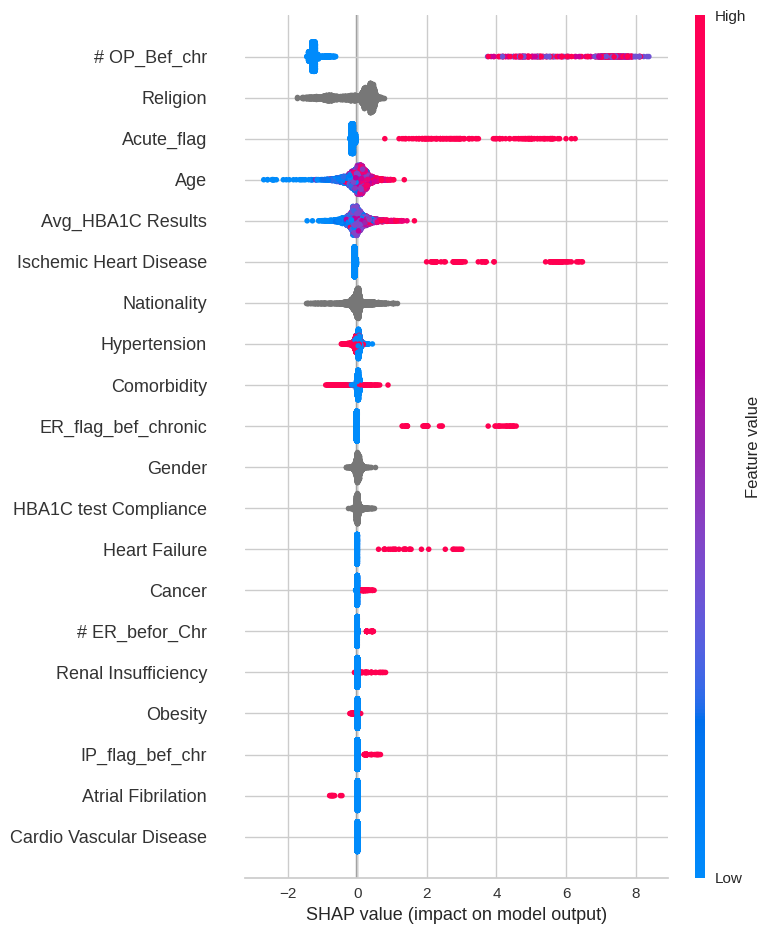

In [ ]:
exp.interpret_model(model, plot='summary')

In [ ]:
# Reason plot for one specific observation in the test set
exp.interpret_model(best, plot='reason', observation=1)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9012,0.8825,0.6676,0.9782,0.7936,0.7316,0.7547


,Samples,Accuracy,AUC,Recall,Precision,F1,Kappa,MCC,Selection Rate
Gender,,,,,,,,,
Female,1772,0.904063,0.8269,0.657676,0.984472,0.788557,0.729655,0.754487,0.181716
Male,2012,0.898608,0.833934,0.67563,0.973366,0.797619,0.73289,0.754631,0.205268


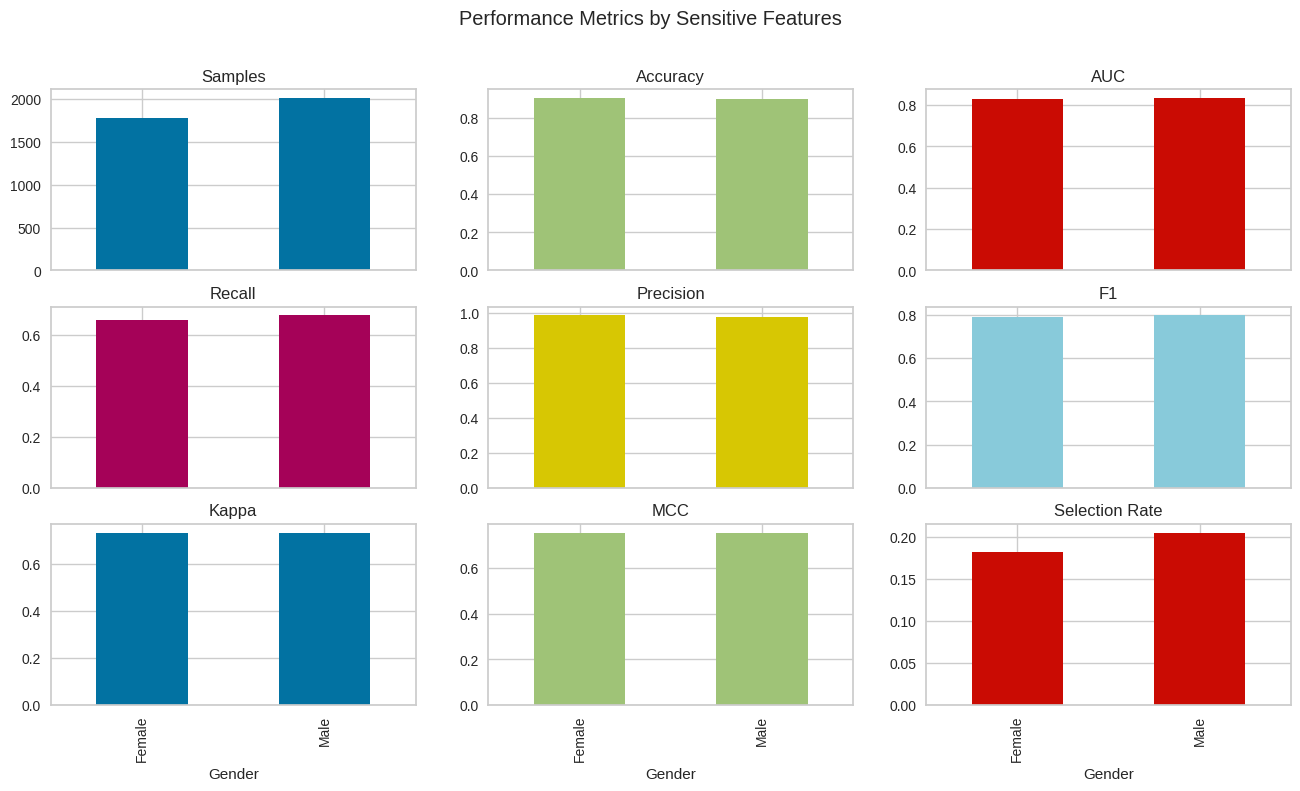

In [ ]:
# Fairness check directly from your experiment
exp.check_fairness(best, sensitive_features=['Gender'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9012,0.8825,0.6676,0.9782,0.7936,0.7316,0.7547


,Samples,Accuracy,Recall,Precision,F1,Kappa,MCC,Selection Rate
Religion,,,,,,,,
CHRISTIAN,2,1.0,0.0,0.0,0.0,NaN,0.0,0.0
Catholic,2,1.0,1.0,1.0,1.0,1.0,1.0,0.5
Christian,9,1.0,1.0,1.0,1.0,1.0,1.0,0.222222
HINDU,1,1.0,0.0,0.0,0.0,NaN,0.0,0.0
ISLAM,323,0.904025,0.651163,0.982456,0.783217,0.724804,0.750087,0.176471
Islam,2412,0.881426,0.654822,0.973585,0.783005,0.70567,0.731942,0.219735
JEWISH,219,0.945205,0.647059,1.0,0.785714,0.755944,0.779515,0.100457
MUSLIM,19,1.0,1.0,1.0,1.0,1.0,1.0,0.157895
Methodist,1,1.0,0.0,0.0,0.0,NaN,0.0,0.0


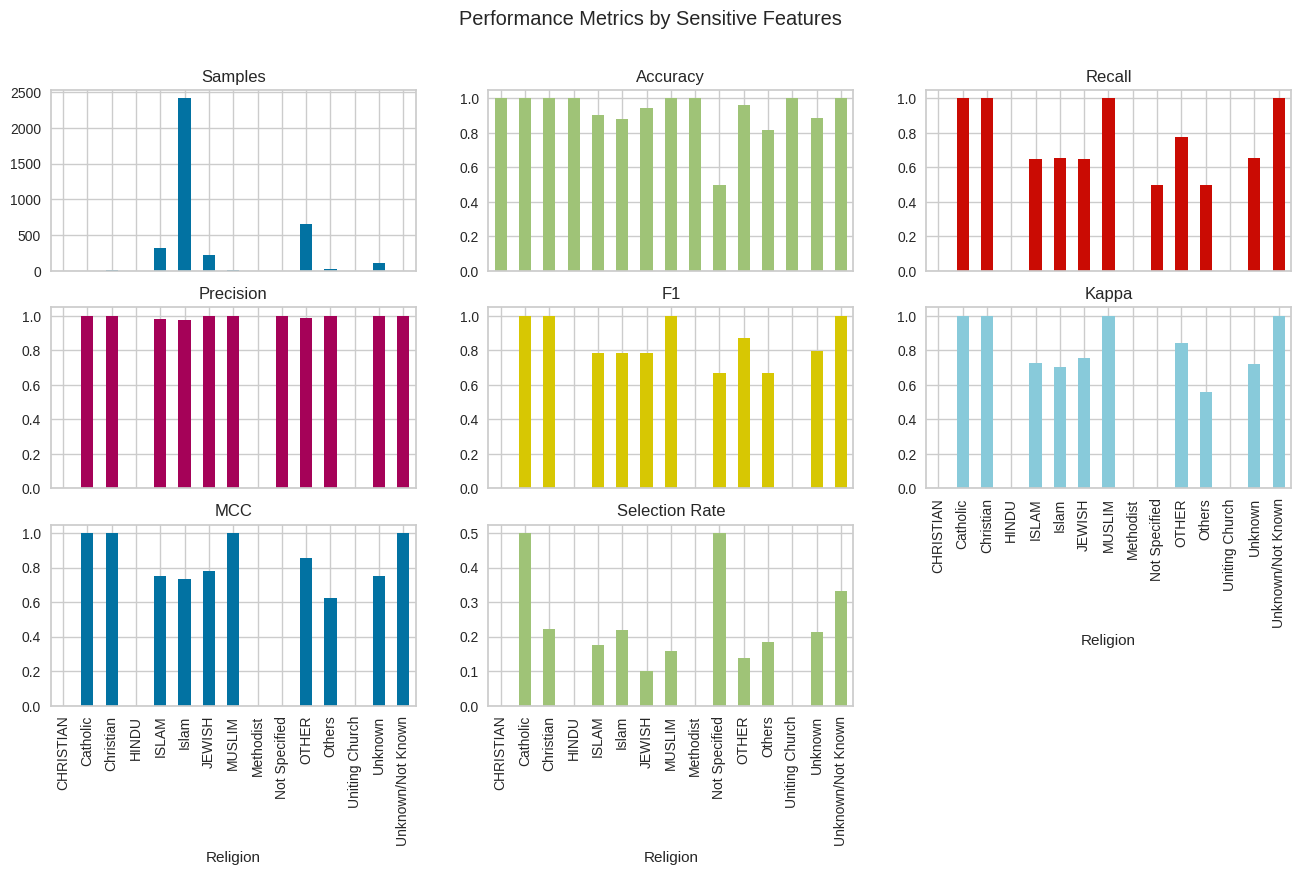

In [ ]:
# Fairness check for Religion
exp.check_fairness(best, sensitive_features=['Religion'])

In [ ]:
exp.setup(
    data=data,
    target=target_col,
    session_id=123,
    ignore_features=[id_col]
)

,Description,Value
0,Session id,123
1,Target,Chronic_flag
2,Target type,Binary
3,Original data shape,"(12611, 27)"
4,Transformed data shape,"(12611, 46)"
5,Transformed train set shape,"(8827, 46)"
6,Transformed test set shape,"(3784, 46)"
7,Ignore features,1
8,Numeric features,6
9,Categorical features,19


In [ ]:
exp.setup(
    data=data,
    target=target_col,
    session_id=123,
    ignore_features=[id_col],
    categorical_features=['Gender', 'Religion', 'Nationality', 'HBA1C test Compliance', 'Diagnosis_Type']  # add others if needed
)

,Description,Value
0,Session id,123
1,Target,Chronic_flag
2,Target type,Binary
3,Original data shape,"(12611, 27)"
4,Transformed data shape,"(12611, 46)"
5,Transformed train set shape,"(8827, 46)"
6,Transformed test set shape,"(3784, 46)"
7,Ignore features,1
8,Numeric features,6
9,Categorical features,5


In [ ]:
# Train a Decision Tree safely
dt = exp.create_model('dt')

# Open dashboard
exp.dashboard(dt, display_format='inline')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8347,0.7955,0.6892,0.7178,0.7033,0.5887,0.5890
1,0.8199,0.7833,0.7052,0.6756,0.6901,0.5632,0.5635
2,0.8256,0.7705,0.6614,0.7064,0.6831,0.5630,0.5636
3,0.8233,0.7806,0.6813,0.6923,0.6867,0.5637,0.5638
4,0.8256,0.7879,0.6693,0.7029,0.6857,0.5651,0.5654
5,0.8324,0.8043,0.7012,0.7068,0.7040,0.5871,0.5871
6,0.8347,0.7930,0.7063,0.7120,0.7092,0.5937,0.5937
7,0.8469,0.8082,0.6972,0.7479,0.7216,0.6163,0.6170
8,0.8401,0.8112,0.7450,0.7083,0.7262,0.6134,0.6138


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Generating self.shap_explainer = shap.TreeExplainer(model)
Building ExplainerDashboard..
For this type of model and model_output interactions don't work, so setting shap_interaction=False...
The explainer object has no decision_trees property. so setting decision_trees=False...
Generating layout...
Calculating shap values...
Calculating prediction probabilities...
Calculating metrics...
Calculating confusion matrices...
Calculating classification_dfs...
Calculating roc auc curves...
Calculating pr auc curves...
Calculating liftcurve_dfs...
Calculating dependencies...
Calculating permutation importances (if slow, try setting n_jobs parameter)...
Calculating pred_percentiles...
Calculating predictions...
Reminder: you can store the explainer (including calculated dependencies) with explainer.dump('explainer.joblib') and reload with e.g. ClassifierExplainer.from_file('explainer.joblib')
Registering callbacks...
Starting ExplainerDashboard inline (terminate it with ExplainerDashboard.termi

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>